# 02 — Feature Engineering, Scaling & Chronological Split
### Continuing from `01_data_cleaning_and_eda.ipynb`

This notebook covers the rest of **Phase 1**: temporal feature extraction,
MinMax scaling, and a strict chronological (non-shuffled) train/test split —
all executed against the real cleaned Tetouan City dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", palette="viridis")

df = pd.read_csv("../data/processed/cleaned.csv", parse_dates=["datetime"])
print(df.shape)
df.head(3)


(52416, 9)


## 2.1 Temporal feature extraction

In [2]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek       # Mon=0 ... Sun=6
df["month"] = df["datetime"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Morocco 2017 public holidays affecting Tetouan (a representative subset:
# New Year's Day, Independence Manifesto Day, Labour Day, Throne Day,
# Oued Ed-Dahab Day, Revolution Day, Youth Day, Green March Day, Independence Day).
# Note: Eid al-Fitr / Eid al-Adha / Islamic New Year are lunar-calendar and shift
# year to year -- for a production system, pull these from a maintained calendar API.
MOROCCO_HOLIDAYS_2017 = {
    pd.Timestamp("2017-01-01").date(),  # New Year's Day
    pd.Timestamp("2017-01-11").date(),  # Independence Manifesto Day
    pd.Timestamp("2017-05-01").date(),  # Labour Day
    pd.Timestamp("2017-07-30").date(),  # Throne Day
    pd.Timestamp("2017-08-14").date(),  # Oued Ed-Dahab Day
    pd.Timestamp("2017-08-20").date(),  # Revolution Day
    pd.Timestamp("2017-08-21").date(),  # Youth Day
    pd.Timestamp("2017-11-06").date(),  # Green March Day
    pd.Timestamp("2017-11-18").date(),  # Independence Day
}
is_named_holiday = df["datetime"].dt.date.isin(MOROCCO_HOLIDAYS_2017)
is_sunday = df["day_of_week"] == 6
df["is_holiday"] = (is_named_holiday | is_sunday).astype(int)

print(f"Rows flagged as holiday: {df['is_holiday'].sum()} ({df['is_holiday'].mean()*100:.1f}%)")
df[["datetime", "hour", "day_of_week", "month", "is_weekend", "is_holiday"]].head()


Rows flagged as holiday: 8352 (15.9%)


## 2.2 Verify the engineered features actually explain load variation

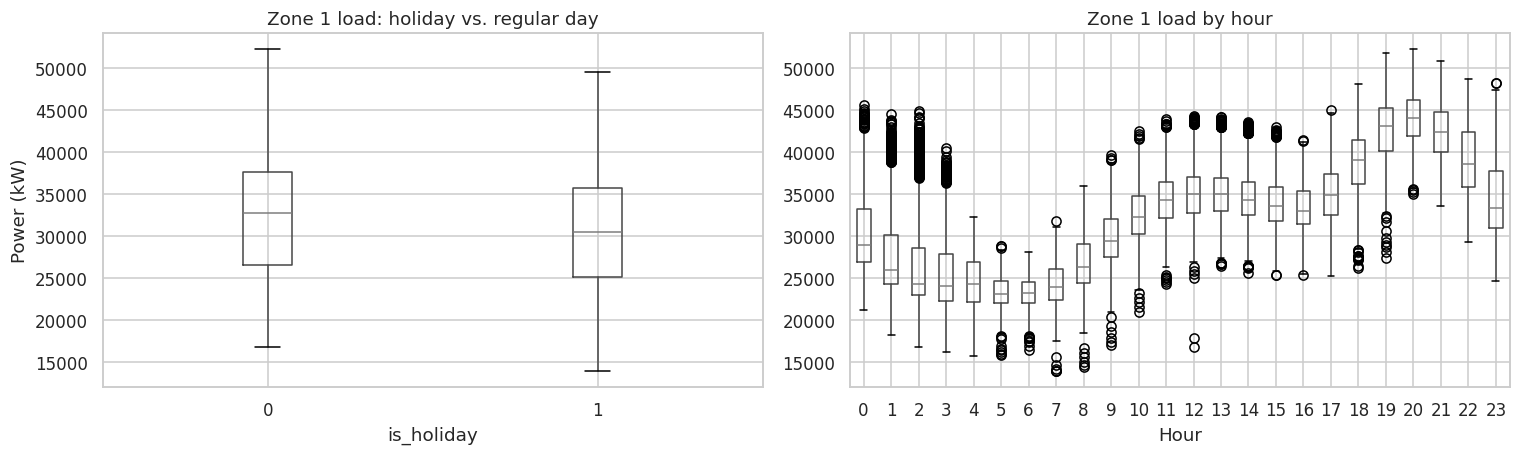

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

df.boxplot(column="power_zone1", by="is_holiday", ax=axes[0])
axes[0].set_title("Zone 1 load: holiday vs. regular day")
axes[0].set_xlabel("is_holiday")
axes[0].set_ylabel("Power (kW)")

df.boxplot(column="power_zone1", by="hour", ax=axes[1])
axes[1].set_title("Zone 1 load by hour")
axes[1].set_xlabel("Hour")
plt.suptitle("")
plt.tight_layout()
plt.show()


Holidays visibly shift the load distribution down, and `hour` alone explains
a large share of the daily variance — both engineered features are earning
their place in the model's input vector.


## 2.3 Assemble the modeling table

In [4]:
FEATURE_COLS = ["temperature", "humidity", "wind_speed", "hour", "day_of_week", "is_holiday"]
TARGET_COL = "power_zone1"

model_df = df[["datetime"] + FEATURE_COLS + [TARGET_COL]].copy()
print(model_df.shape)
model_df.describe().T


(52416, 8)


## 2.4 Chronological 80/20 split (no shuffling — this is time series)

In [5]:
model_df = model_df.sort_values("datetime").reset_index(drop=True)
n = len(model_df)
split_idx = int(n * 0.8)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print(f"Train: {len(train_df):,} rows  ({train_df.datetime.min()}  ->  {train_df.datetime.max()})")
print(f"Test:  {len(test_df):,} rows  ({test_df.datetime.min()}  ->  {test_df.datetime.max()})")
print()
print(f"Train = {len(train_df)/n*100:.1f}% of data, Test = {len(test_df)/n*100:.1f}%")


Train: 41,932 rows  (2017-01-01 00:00:00  ->  2017-10-19 04:30:00)
Test:  10,484 rows  (2017-10-19 04:40:00  ->  2017-12-30 23:50:00)

Train = 80.0% of data, Test = 20.0%


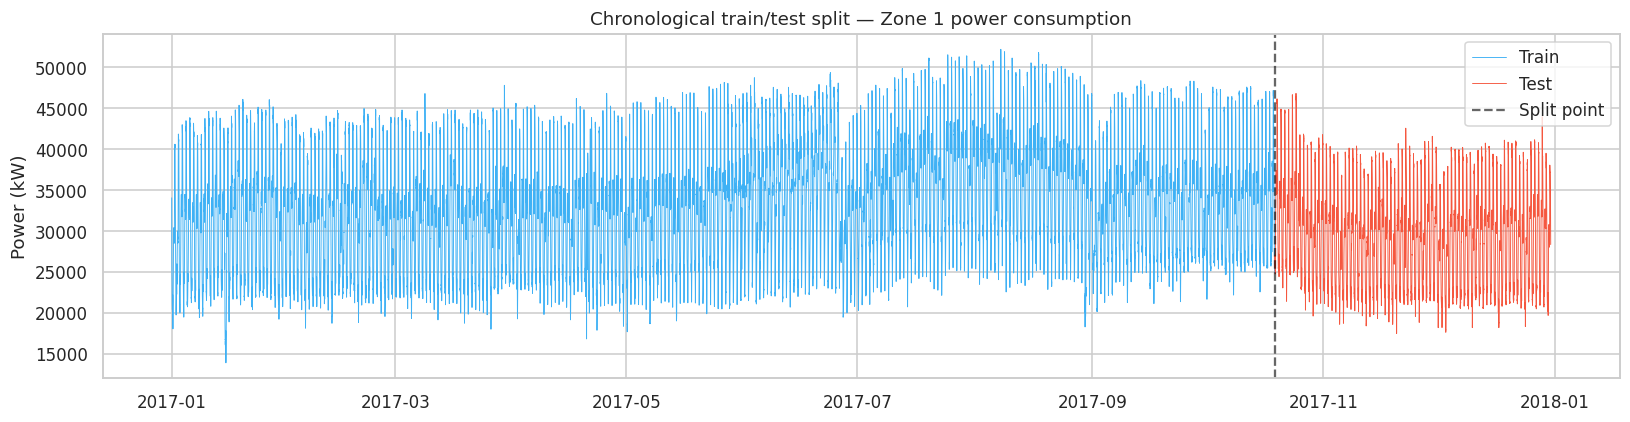

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df.datetime, train_df.power_zone1, color="#3FB1F5", label="Train", linewidth=0.6)
ax.plot(test_df.datetime, test_df.power_zone1, color="#F5573F", label="Test", linewidth=0.6)
ax.axvline(train_df.datetime.max(), color="black", linestyle="--", alpha=0.6, label="Split point")
ax.set_title("Chronological train/test split — Zone 1 power consumption")
ax.set_ylabel("Power (kW)")
ax.legend()
plt.tight_layout()
plt.show()


The split point falls in mid-October 2017 — the model trains on
Jan-through-mid-Oct and is evaluated on unseen mid-Oct-through-Dec data, with
zero shuffling. This is the correct way to validate a time-series regressor:
random shuffling would leak future information into training and produce an
optimistic, unrealistic test score.


## 2.5 MinMax scaling — fit ONLY on the training partition

In [7]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

X_train = feature_scaler.fit_transform(train_df[FEATURE_COLS].values)
X_test = feature_scaler.transform(test_df[FEATURE_COLS].values)

y_train = target_scaler.fit_transform(train_df[[TARGET_COL]].values)
y_test = target_scaler.transform(test_df[[TARGET_COL]].values)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)
print()
print("Post-scaling ranges (train):")
print("  X_train min/max per column:", X_train.min(axis=0).round(3), "/", X_train.max(axis=0).round(3))
print("  y_train min/max:", y_train.min().round(3), "/", y_train.max().round(3))
print()
print("Post-scaling ranges (test -- note these can exceed [0,1] slightly,")
print("since the scaler only ever saw training-period statistics, which is correct):")
print("  X_test min/max per column:", X_test.min(axis=0).round(3), "/", X_test.max(axis=0).round(3))


X_train: (41932, 6)  X_test: (10484, 6)
y_train: (41932, 1)  y_test: (10484, 1)

Post-scaling ranges (train):
  X_train min/max per column: [0. 0. 0. 0. 0. 0.] / [1. 1. 1. 1. 1. 1.]
  y_train min/max: 0.0 / 1.0

Post-scaling ranges (test -- note these can exceed [0,1] slightly,
since the scaler only ever saw training-period statistics, which is correct):
  X_test min/max per column: [0.039 0.061 0.002 0.    0.    0.   ] / [0.706 1.014 1.295 1.    1.    1.   ]


## 2.6 Persist everything the training notebook needs

In [8]:
import joblib, os, json

os.makedirs("../artifacts", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

np.savez("../data/processed/split_arrays.npz",
         X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

joblib.dump(feature_scaler, "../artifacts/feature_scaler.joblib")
joblib.dump(target_scaler, "../artifacts/target_scaler.joblib")

with open("../artifacts/feature_columns.json", "w") as f:
    json.dump({"features": FEATURE_COLS, "target": TARGET_COL}, f, indent=2)

train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Saved: split_arrays.npz, feature_scaler.joblib, target_scaler.joblib, train.csv, test.csv")


Saved: split_arrays.npz, feature_scaler.joblib, target_scaler.joblib, train.csv, test.csv


---
**Summary of Phase 1, part 2:**
- Engineered `hour`, `day_of_week`, `month`, `is_weekend`, `is_holiday` from the real timestamp column.
- Holiday flag combines a real Morocco 2017 public-holiday calendar with a Sunday proxy.
- Verified visually that both `hour` and `is_holiday` shift the load distribution — they carry real signal.
- Split chronologically at 80/20 (train: Jan-mid Oct 2017, test: mid Oct-Dec 2017), zero shuffling.
- Fit `MinMaxScaler` for features and target **only on the training partition**, to avoid leakage.
- Saved `X_train/X_test/y_train/y_test` + both scalers to `artifacts/` for the next notebook.

Continue to **`03_model_training.ipynb`**.
